In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mnp.config import INTERIM_DATA_DIR
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0})

2026-06-15 04:07:14.599 | INFO     | mnp.config:<module>:11 - PROJ_ROOT path is: /Users/abelguevarah/Desktop/invs/malnutrition-research


In [2]:
DATA_PATH = INTERIM_DATA_DIR / "rech23_cleaned.parquet"
df_rech23 = pd.read_parquet(DATA_PATH)
print(f"Hogares totales: {len(df_rech23):,}")
print(f"Columnas extraídas (Raw kept): {len(df_rech23.columns)}")

Hogares totales: 607,287
Columnas extraídas (Raw kept): 93


# EDA 3 (Interim) - RECH23: Riqueza, Geografía e Infraestructura Extendida

Este cuaderno analiza las variables estructurales del hogar que sobrevivieron a la fase de prelimpieza (decididas explícitamente en el documento `decisiones-de-limpieza-not-drops.md` y configuradas en `rech23.py`).

> [!NOTE]
> **Sobre la preservación del Dataset (93 Columnas)**
> El archivo `rech23_cleaned.parquet` contiene **93 variables estructurales** que fueron rescatadas y limpiadas meticulosamente (esto incluye variables minuciosas como tenencia de bicicletas, material de ventanas, tipo de recojo de basura, etc.). 
> **Es fundamental aclarar que NINGUNA de estas 93 variables ha sido descartada del proyecto.** Todas ellas pasarán intactas a la fase de *Feature Engineering* y *Modelado*, donde la Inteligencia Artificial (Random Forest / XGBoost) utilizará la totalidad de las 93 columnas para cazar patrones matemáticos ocultos de pobreza profunda.
> 
> **¿Por qué no se grafican las 93 variables aquí?**
> El objetivo de un *Análisis Exploratorio de Datos (EDA)* visual no es producir 93 gráficos estadísticos consecutivos, ya que esto causaría fatiga visual y ocultaría las tendencias estratégicas. En su lugar, hemos agrupado y seleccionado visualmente los **"Mega-Predictores Estructurales"** (Riqueza absoluta, Agua, Desagüe, Piso de tierra, Tipo de combustible y Conectividad). Estos pilares engloban los vectores biológicos directos de infección, hacinamiento y aislamiento que causan la desnutrición infantil.
> 
> Para mantener el rigor longitudinal del proyecto, todas las visualizaciones se cruzan **por año (2007-2024)**, permitiendo evidenciar la Transición Tecnológica y Sanitaria del Perú y vigilar posibles saltos metodológicos en el muestreo del INEI.

## 1. El Predictor Maestro: Índice de Riqueza (`HV270`)

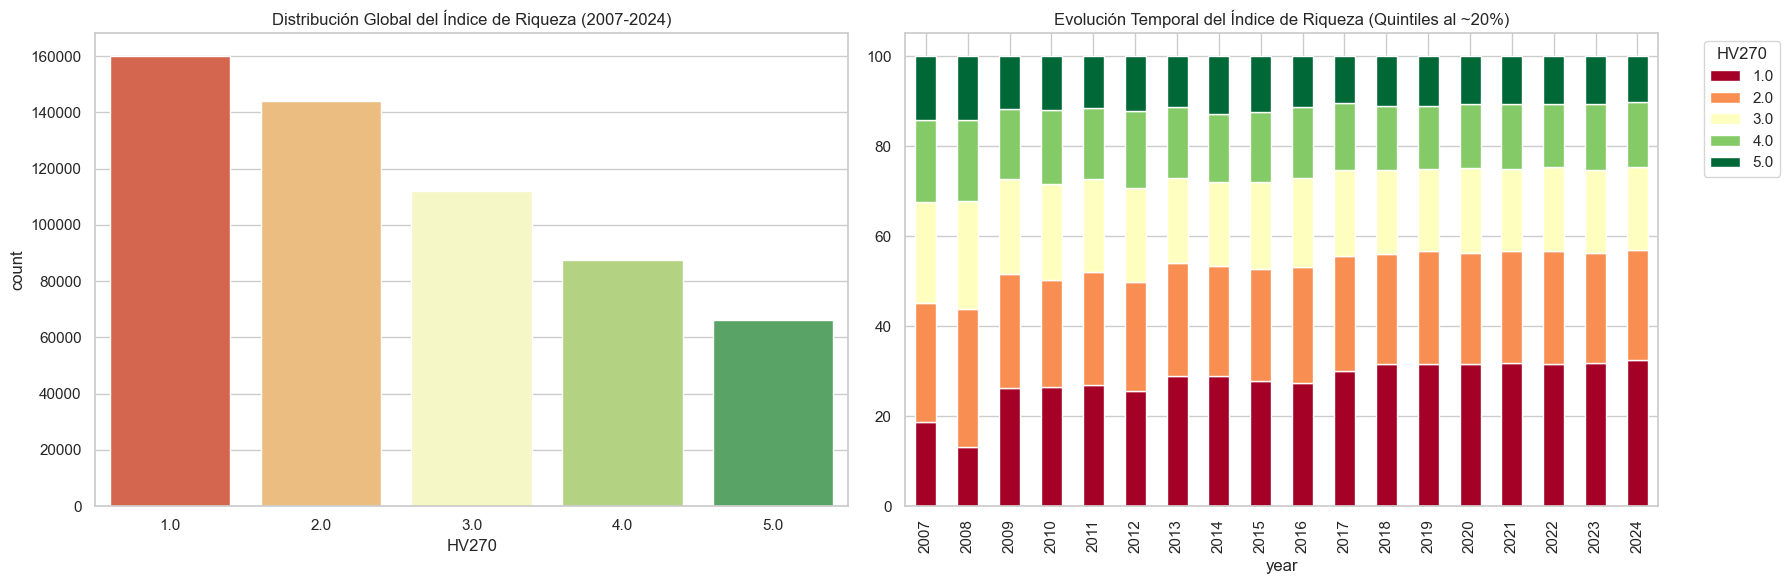

In [3]:
df_wealth = df_rech23.dropna(subset=['HV270', 'year'])
wealth_balance = pd.crosstab(df_wealth['year'], df_wealth['HV270'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.countplot(data=df_wealth, x='HV270', palette='RdYlGn', ax=axes[0])
axes[0].set_title('Distribución Global del Índice de Riqueza (2007-2024)')

wealth_balance.plot(kind='bar', stacked=True, ax=axes[1], colormap='RdYlGn')
axes[1].set_title('Evolución Temporal del Índice de Riqueza (Quintiles al ~20%)')
axes[1].legend(title='HV270', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

> **Conclusión y Acción (Índice de Riqueza - HV270)**
> * **Observación:** El gráfico destruye el mito estadístico de los "Quintiles Exactos" (donde cada estrato debería ser el 20%). Vemos una clara "escalera de pobreza" global. Además, a partir de la expansión de muestra (post-2014), los quintiles 1 (Extrema Pobreza) y 2 **suman casi el 60%** de toda la data encuestada anualmente, mientras que el quintil 5 (Más Ricos) apenas supera el 10%.
> * **Acción a Tomar:** **Dataset Altamente Focalizado.** Esto valida metodológicamente la ENDES como una encuesta de Salud Pública y no de consumo. El dataset está fuertemente sesgado hacia nuestro público de interés epidemiológico. La IA tendrá un volumen masivo de datos en los estratos bajos, lo que le permitirá cazar patrones sutiles de supervivencia (ej. ¿Por qué un niño pobre se desnutre y otro niño igualmente pobre no? La respuesta estará en las siguientes variables de infraestructura y saneamiento).

## 2. Saneamiento, Higiene y Vectores Biológicos
Aquí agrupamos los vectores de infección directos (agua, desagüe, piso).

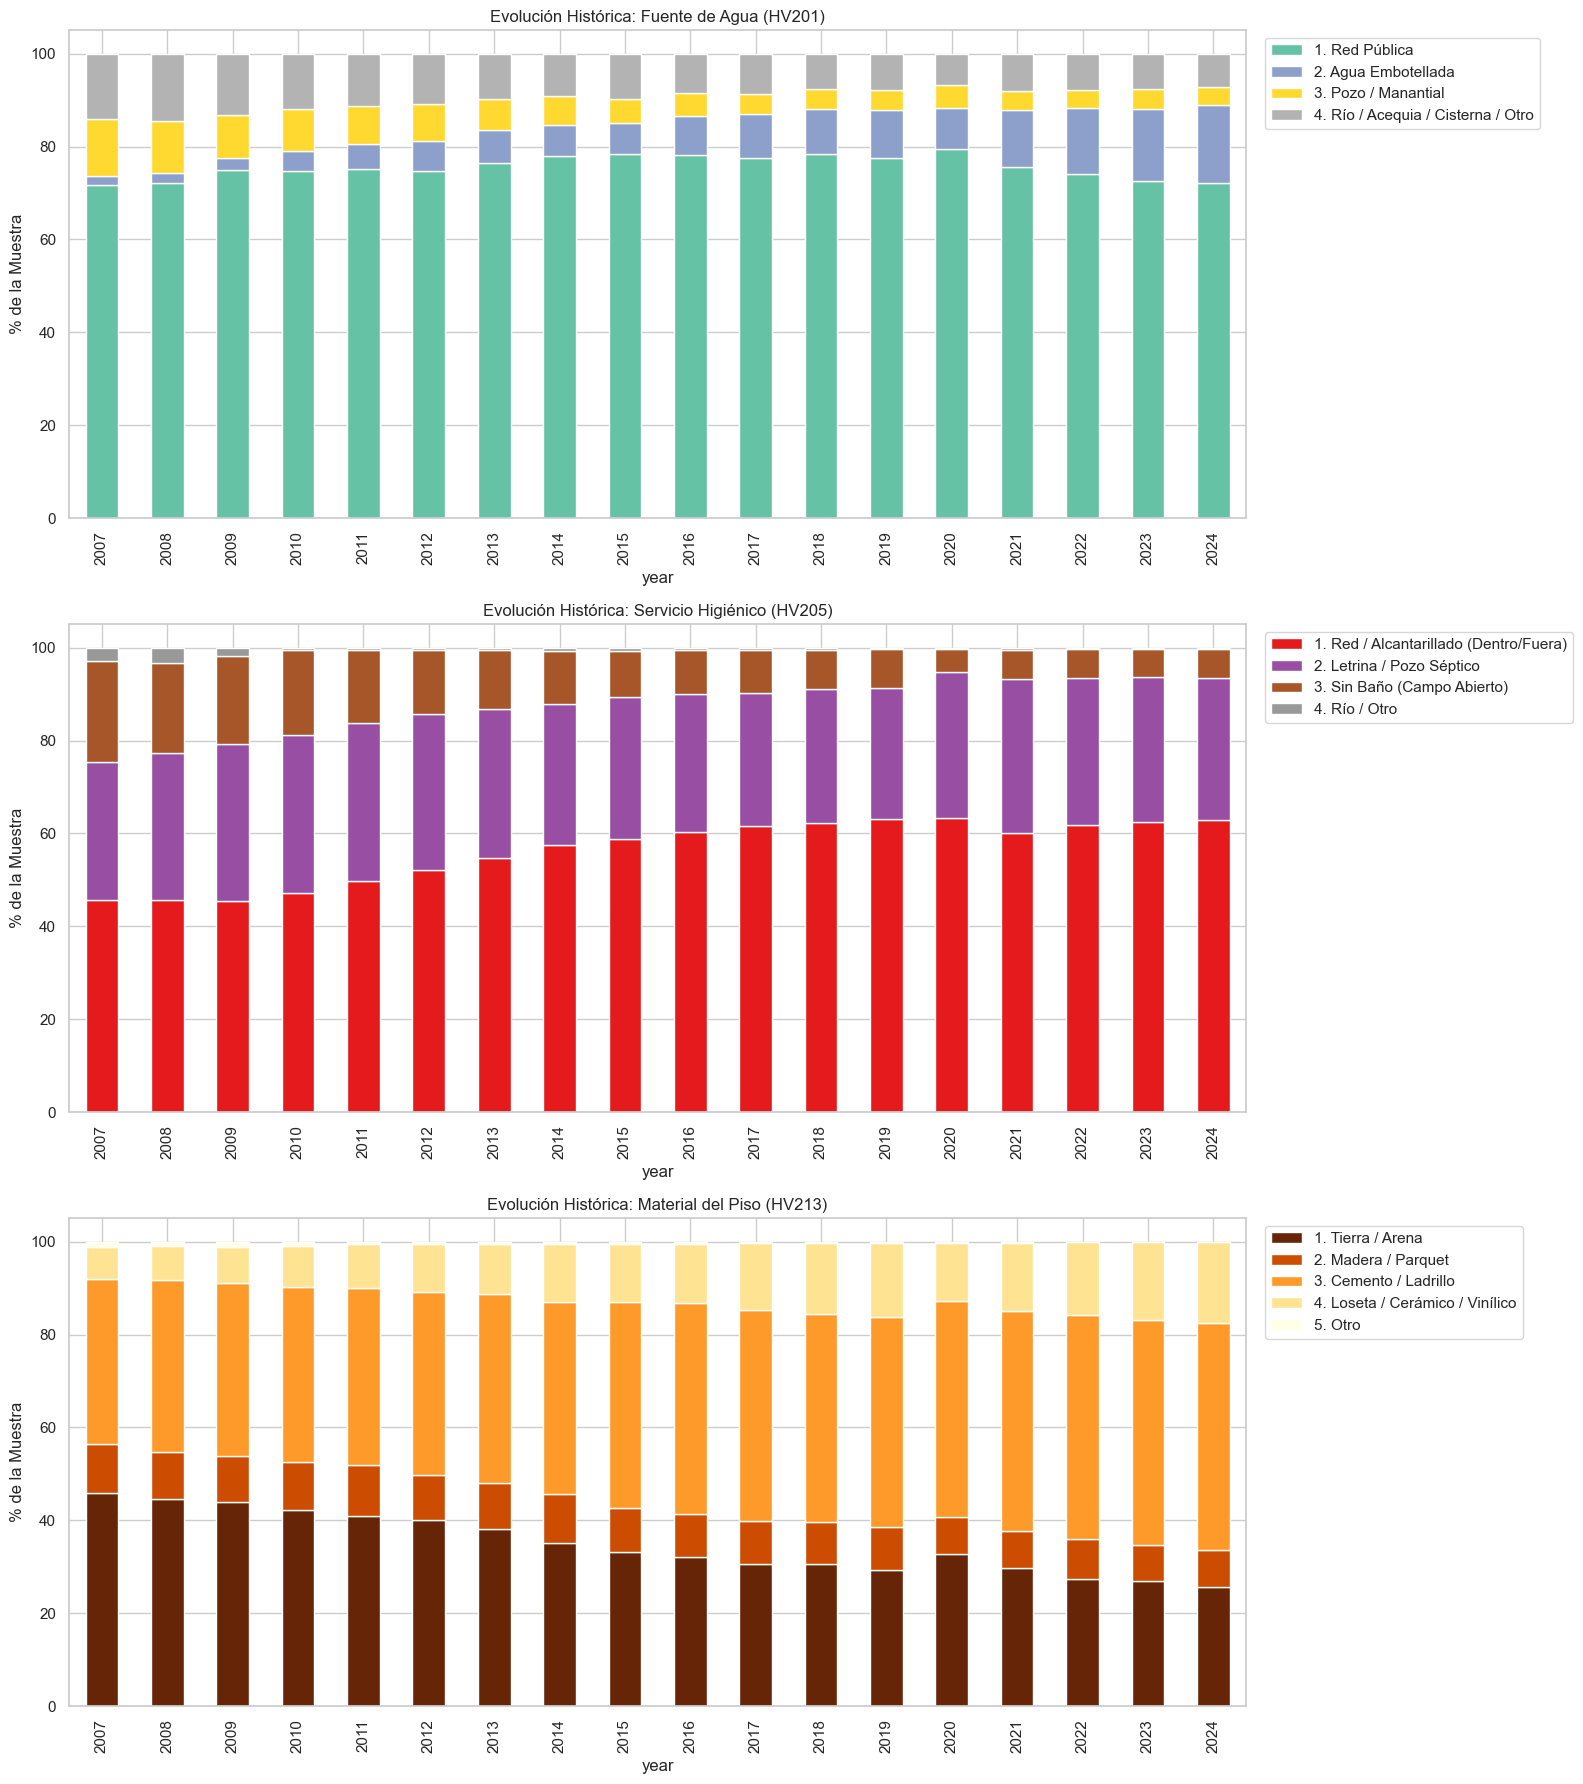

In [4]:
def simpl_agua(x):
    if pd.isna(x): return np.nan
    x = str(x).strip()
    if x in ['Red dentro de vivienda', 'Red fuera de la vivienda pero dentro de la edificación', 'Pilón, grifo público']: return '1. Red Pública'
    if x in ['Agua embotellada']: return '2. Agua Embotellada'
    if x in ['Pozo dentro de vivienda', 'Pozo público', 'Manantial']: return '3. Pozo / Manantial'
    return '4. Río / Acequia / Cisterna / Otro'

def simpl_bano(x):
    if pd.isna(x): return np.nan
    x = str(x).strip()
    if x in ['Dentro de la vivienda', 'Fuera de la vivienda, pero dentro del edificio']: return '1. Red / Alcantarillado (Dentro/Fuera)'
    if x in ['Latrina (pozo ciego o negro)', 'Letrina mejorada ventilada', 'Pozo séptico', 'Latrina mejorada colgada/flotante']: return '2. Letrina / Pozo Séptico'
    if x in ['Sin servicio (matorral/campo)']: return '3. Sin Baño (Campo Abierto)'
    return '4. Río / Otro'

def simpl_piso(x):
    if pd.isna(x): return np.nan
    x = str(x).strip()
    if x in ['Tierra / arena']: return '1. Tierra / Arena'
    if x in ['Madera', 'Parquet o madera pulida']: return '2. Madera / Parquet'
    if x in ['Cemento / ladrillo']: return '3. Cemento / Ladrillo'
    if x in ['Losetas, terrazos o similares', 'Láminas asfálticas, vinílicos o similares']: return '4. Loseta / Cerámico / Vinílico'
    return '5. Otro'

df_rech23['Water_Cat'] = df_rech23['HV201'].apply(simpl_agua)
df_rech23['Toilet_Cat'] = df_rech23['HV205'].apply(simpl_bano)
df_rech23['Floor_Cat'] = df_rech23['HV213'].apply(simpl_piso)

fig, axes = plt.subplots(3, 1, figsize=(16, 18))

for i, (col, title, cmap) in enumerate(zip(
    ['Water_Cat', 'Toilet_Cat', 'Floor_Cat'],
    ['Fuente de Agua (HV201)', 'Servicio Higiénico (HV205)', 'Material del Piso (HV213)'],
    ['Set2', 'Set1', 'YlOrBr_r'])):
    
    df_sub = df_rech23.dropna(subset=[col, 'year'])
    cross = pd.crosstab(df_sub['year'], df_sub[col], normalize='index') * 100
    
    cross = cross.reindex(columns=sorted(cross.columns))
    cross.plot(kind='bar', stacked=True, ax=axes[i], colormap=cmap)
    axes[i].set_title(f'Evolución Histórica: {title}')
    axes[i].set_ylabel('% de la Muestra')
    axes[i].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

> **Conclusión y Acción (Saneamiento y Vectores Biológicos - HV201, HV205, HV213)**
> * **Agua (HV201):** Hallazgo fascinante: el consumo de **Agua Embotellada** (franja azul) explotó de casi 0% en 2007 a casi 18% en 2024, robándole terreno a la Red Pública. Esto refleja una profunda desconfianza moderna en la salubridad del agua de grifo.
> * **Baño (HV205):** Gigantesca victoria en salud pública: la letal práctica de defecación a "Campo Abierto" (marrón) colapsó del 22% al 5%. La Red de Alcantarillado avanzó hasta el 62%.
> * **Pisos (HV213):** El piso de "Tierra" (marrón oscuro) se redujo dramáticamente del 45% al 25%, cediendo paso al "Cemento". Sin embargo, ese **25% residual de hogares con piso de tierra en pleno 2024 es una alerta máxima**.
> * **Acción a Tomar:** **La "Trinidad Biológica".** Estas tres columnas son infinitamente más predictivas que la pobreza abstracta. Un niño que gatea en un piso de tierra (`HV213`), convive con letrinas/campo (`HV205`) y toma agua sin tratar (`HV201`) es candidato directo a sufrir *Enteropatía Ambiental* (inflamación crónica del intestino que bloquea la absorción de hierro y proteínas). El modelo XGBoost usará la interacción de estas tres variables como el penalizador de riesgo de desnutrición más severo de todo el dataset.

## 3. Infraestructura Básica y Hacinamiento (`HV214`, `HV215`, `HV216`)
Materiales de paredes/techo y la cantidad de cuartos analizados temporalmente.

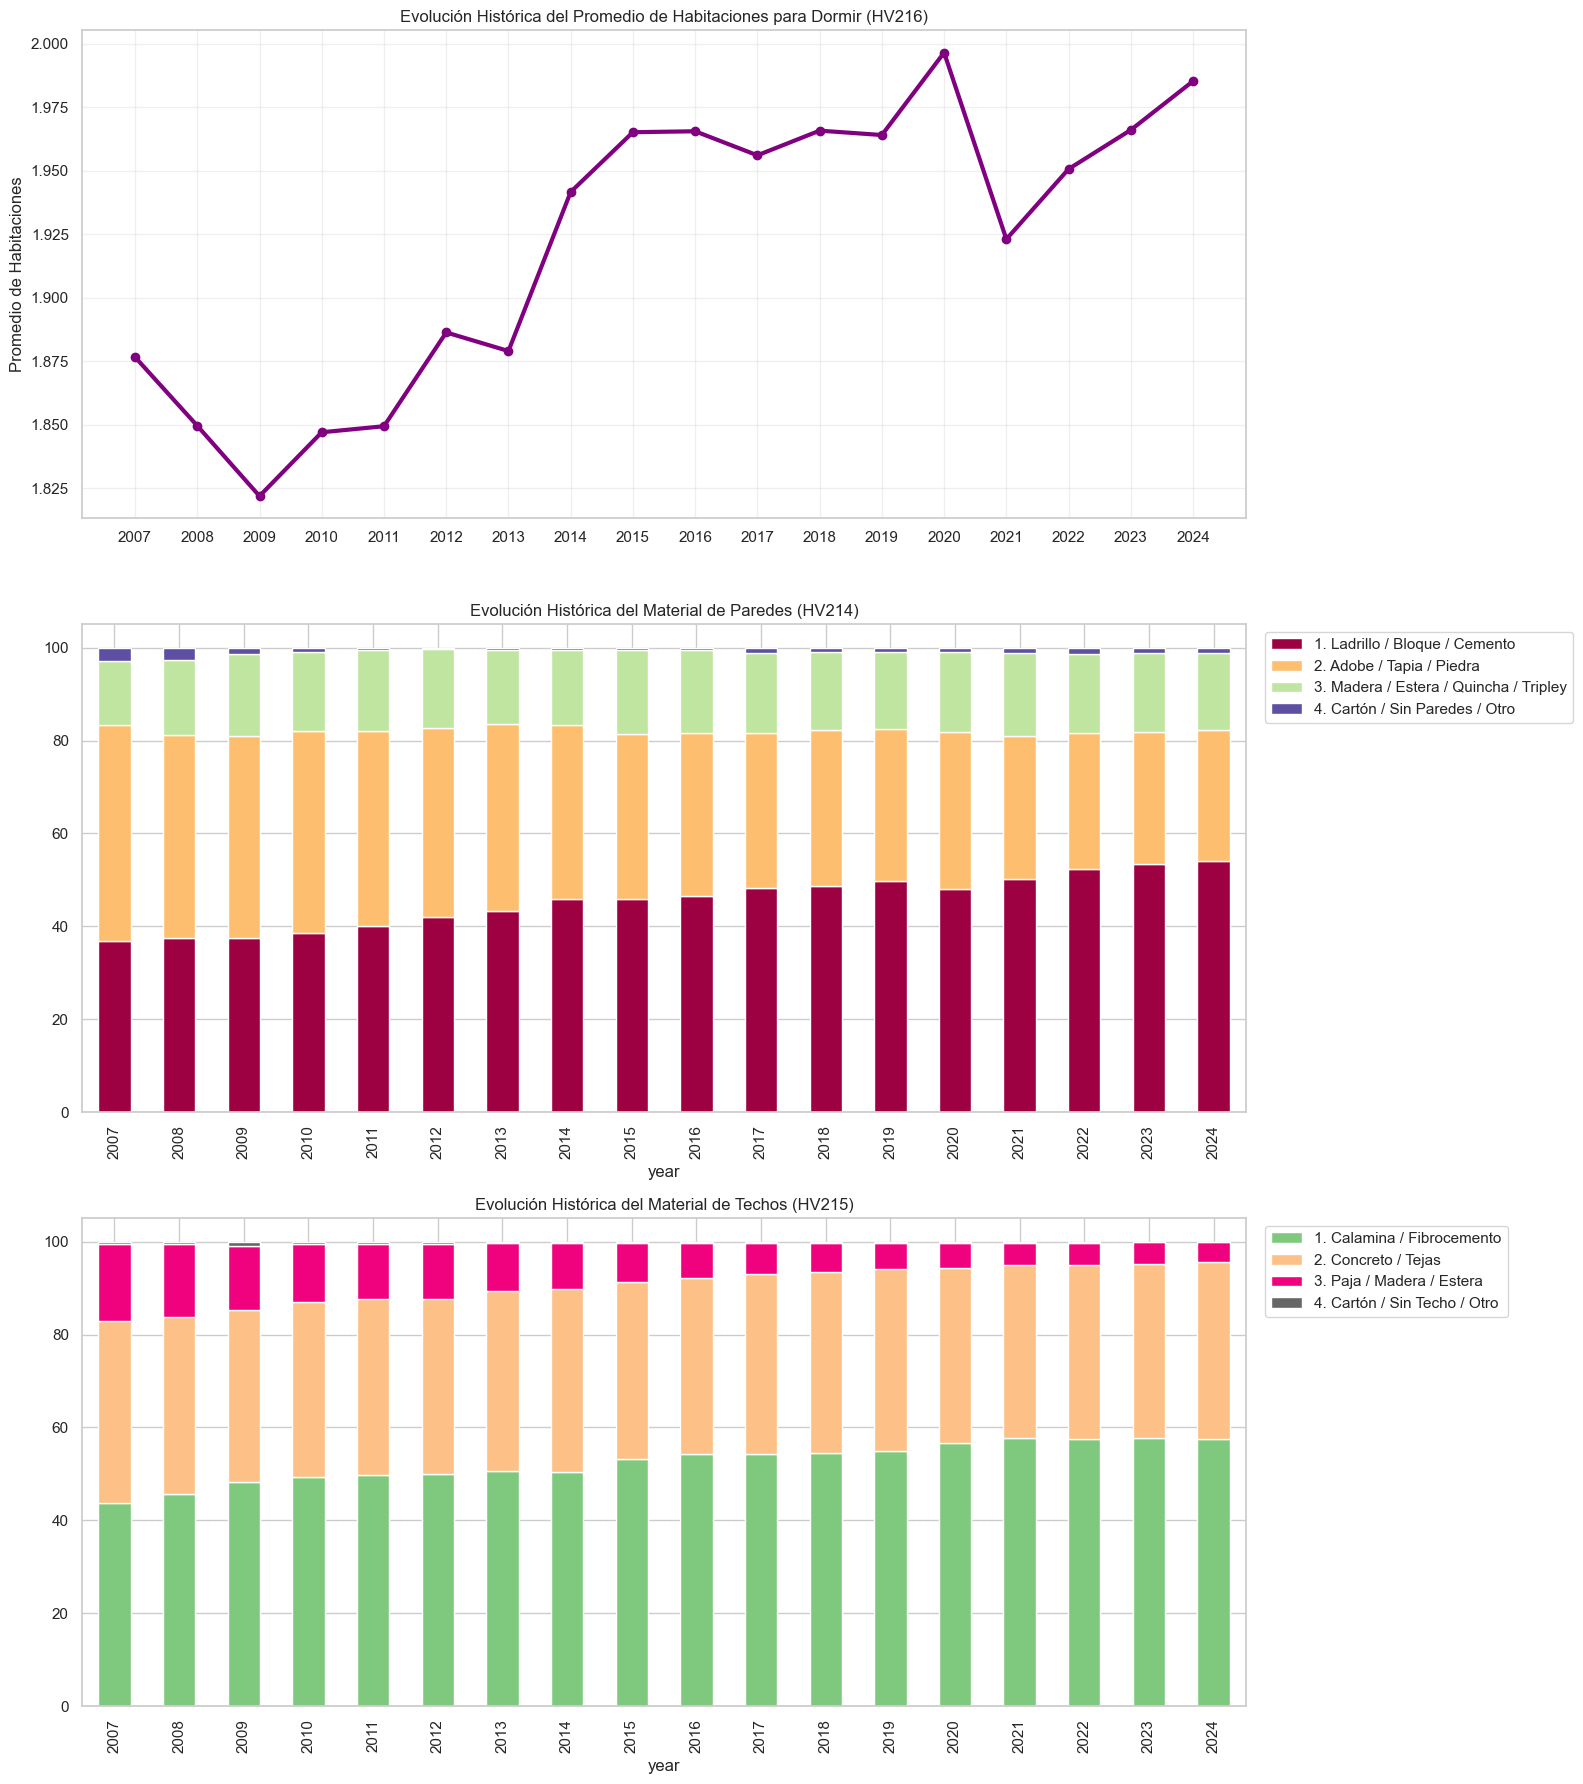

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(16, 18))

# Promedio de Habitaciones por Año (HV216)
df_rooms = df_rech23.dropna(subset=['HV216', 'year'])
rooms_mean = df_rooms.groupby('year')['HV216'].mean()
axes[0].plot(rooms_mean.index, rooms_mean.values, marker='o', color='purple', linewidth=3)
axes[0].set_title('Evolución Histórica del Promedio de Habitaciones para Dormir (HV216)')
axes[0].set_ylabel('Promedio de Habitaciones')
axes[0].set_xticks(rooms_mean.index)
axes[0].grid(True, alpha=0.3)

# Paredes por Año (HV214)
def simpl_pared(x):
    if pd.isna(x): return np.nan
    x = str(x).strip()
    if x in ['Ladrillo o bloques de cemento', 'Piedra o sillar con cal o cemento']: return '1. Ladrillo / Bloque / Cemento'
    if x in ['Adobe o tapia', 'Piedra con barro']: return '2. Adobe / Tapia / Piedra'
    if x in ['Tablones/Madera', 'Quincha (caña con barro)', 'Tripley', 'Caña/Bambu/Pona/Palma/Troncos/Tabique', 'Estera']: return '3. Madera / Estera / Quincha / Tripley'
    return '4. Cartón / Sin Paredes / Otro'

if 'HV214' in df_rech23.columns:
    df_rech23['Wall_Cat'] = df_rech23['HV214'].apply(simpl_pared)
    df_wall = df_rech23.dropna(subset=['Wall_Cat', 'year'])
    wall_cross = pd.crosstab(df_wall['year'], df_wall['Wall_Cat'], normalize='index') * 100
    wall_cross = wall_cross.reindex(columns=sorted(wall_cross.columns))
    wall_cross.plot(kind='bar', stacked=True, ax=axes[1], colormap='Spectral')
    axes[1].set_title('Evolución Histórica del Material de Paredes (HV214)')
    axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

# Techo por Año (HV215)
def simpl_techo(x):
    if pd.isna(x): return np.nan
    x = str(x).strip()
    if x in ['Plancha de calamina, fibra de cemento o similares']: return '1. Calamina / Fibrocemento'
    if x in ['Concreto armado', 'Tejas']: return '2. Concreto / Tejas'
    if x in ['Paja, hojas de palmera etc.', 'Caña o estera en torta de barro', 'Madera', 'Estera']: return '3. Paja / Madera / Estera'
    return '4. Cartón / Sin Techo / Otro'

if 'HV215' in df_rech23.columns:
    df_rech23['Roof_Cat'] = df_rech23['HV215'].apply(simpl_techo)
    df_roof = df_rech23.dropna(subset=['Roof_Cat', 'year'])
    roof_cross = pd.crosstab(df_roof['year'], df_roof['Roof_Cat'], normalize='index') * 100
    roof_cross = roof_cross.reindex(columns=sorted(roof_cross.columns))
    roof_cross.plot(kind='bar', stacked=True, ax=axes[2], colormap='Accent')
    axes[2].set_title('Evolución Histórica del Material de Techos (HV215)')
    axes[2].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

> **Conclusión y Acción (Estructura y Hacinamiento - HV214, HV215, HV216)**
> * **Habitaciones (HV216):** La gráfica morada de promedios revela dos "terremotos" estadísticos. Primero, un salto escalonado entre 2013-2015, confirmando definitivamente que la expansión de muestra del INEI trajo a la base de datos a familias más grandes. Segundo, un desplome anómalo y brusco en 2021, que probablemente captura el hacinamiento extremo causado por la crisis económica del COVID-19 (familias reagrupándose en menos cuartos).
> * **Paredes (HV214) y Techos (HV215):** Observamos la transición hacia la urbanización precaria. Las paredes de Ladrillo (rojo oscuro) desplazaron al Adobe (naranja), pasando de un 37% a un 55%. Simultáneamente, el techo de Calamina (verde) reina como el estándar peruano moderno (casi 60%), exterminando a los techos tradicionales de paja o estera (fucsia).
> * **Acción a Tomar:** **Vector de Hacinamiento.** El número de cuartos (`HV216`) será oro puro para el modelo si lo cruzamos matemáticamente con el total de habitantes del hogar para crear un *Ratio de Hacinamiento*. Dormir hacinados es el canal número uno de transmisión cruzada de infecciones respiratorias crónicas, las cuales debilitan el sistema inmune del niño y catalizan la desnutrición.

## 4. Energía y Contaminación Intradomiciliaria (`HV206`, `HV226`)

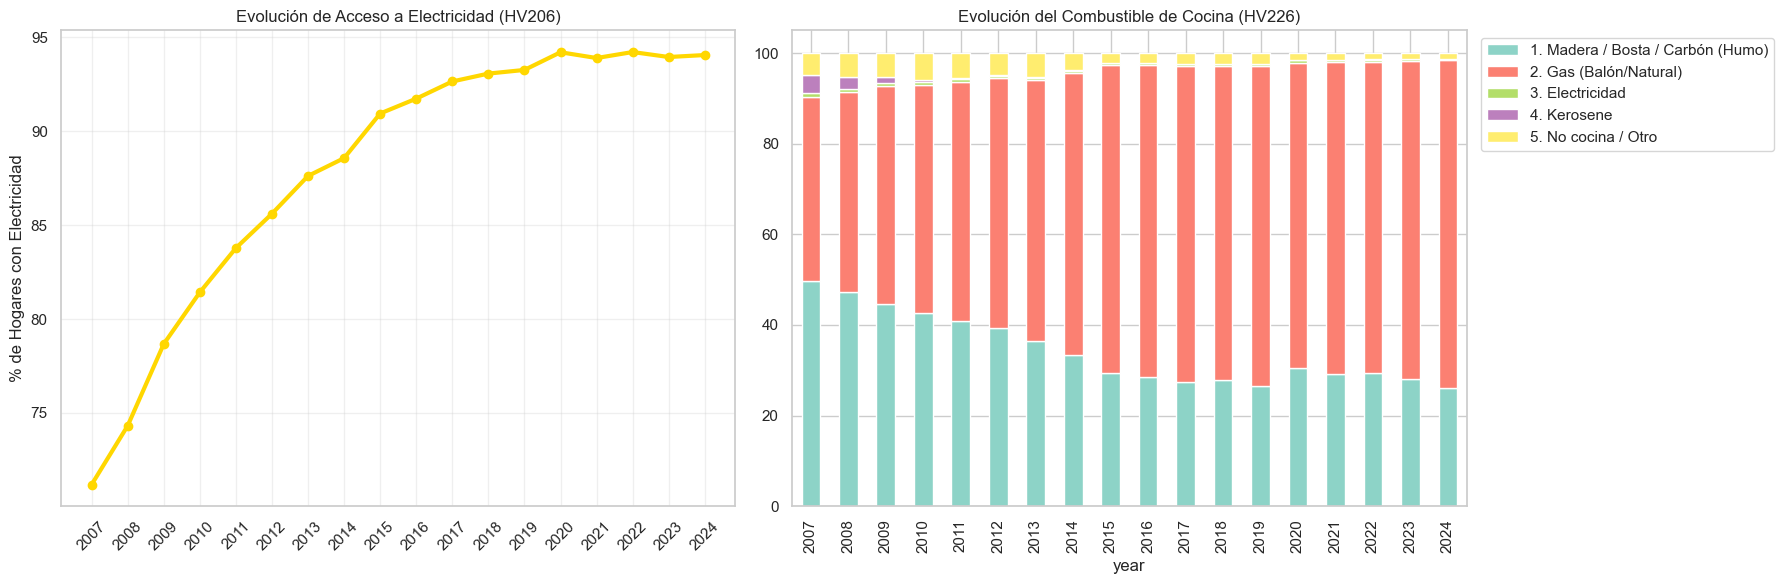

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Electricidad (HV206) - Binaria
if 'HV206' in df_rech23.columns:
    df_elec = df_rech23.dropna(subset=['HV206', 'year'])
    if df_elec['HV206'].dtype == object or str(df_elec['HV206'].iloc[0]).isalpha():
        elec_cross = (df_elec[df_elec['HV206'].astype(str).str.contains('sí|si|yes|1', case=False, na=False)].groupby('year').size() / df_elec.groupby('year').size()) * 100
    else:
        elec_cross = (df_elec[df_elec['HV206'] == 1.0].groupby('year').size() / df_elec.groupby('year').size()) * 100
        
    axes[0].plot(elec_cross.index, elec_cross.values, marker='o', color='gold', linewidth=3)
    axes[0].set_title('Evolución de Acceso a Electricidad (HV206)')
    axes[0].set_ylabel('% de Hogares con Electricidad')
    axes[0].set_xticks(elec_cross.index)
    axes[0].set_xticklabels(elec_cross.index, rotation=45)
    axes[0].grid(True, alpha=0.3)

# Combustible para cocinar (HV226)
def simpl_combustible(x):
    if pd.isna(x): return np.nan
    x = str(x).strip()
    if x in ['Madera', 'Estiércol animal', 'Carbón', 'Paja, arbusto  o césped', 'Carbón, lignito']: return '1. Madera / Bosta / Carbón (Humo)'
    if x in ['LPG', 'Gas natural']: return '2. Gas (Balón/Natural)'
    if x in ['Electricidad']: return '3. Electricidad'
    if x in ['Kerosene']: return '4. Kerosene'
    return '5. No cocina / Otro'

if 'HV226' in df_rech23.columns:
    df_rech23['Fuel_Cat'] = df_rech23['HV226'].apply(simpl_combustible)
    df_fuel = df_rech23.dropna(subset=['Fuel_Cat', 'year'])
    fuel_cross = pd.crosstab(df_fuel['year'], df_fuel['Fuel_Cat'], normalize='index') * 100
    fuel_cross = fuel_cross.reindex(columns=sorted(fuel_cross.columns))
    fuel_cross.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set3')
    axes[1].set_title('Evolución del Combustible de Cocina (HV226)')
    axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

> **Conclusión y Acción (Energía y Contaminación Intradomiciliaria - HV206, HV226)**
> * **Electricidad (HV206):** El gráfico de línea amarilla muestra una victoria histórica en infraestructura: la electrificación de los hogares encuestados subió del 71% (2007) a casi un 94% (2024). Hoy en día, no tener electricidad es un marcador inequívoco de aislamiento geográfico extremo.
> * **Combustible de Cocina (HV226):** Observamos la total extinción del Kerosene (franja morada) a partir del 2010 y la gran expansión del Gas (rojo). Sin embargo, el hallazgo epidemiológico más importante es que el uso de Madera/Bosta (verde claro) cayó del 50% al 25%, pero **se ha quedado estancado ahí en los últimos 5 años**.
> * **Acción a Tomar:** **El "Asesino Silencioso" Respiratorio.** Ese 25% de familias que sigue cocinando con Madera o Bosta es una mina de oro predictiva. Cocinar con leña en interiores genera humo constante. Los infantes respiran este humo y desarrollan cuadros de inflamación respiratoria crónica. Biológicamente, esto obliga al cuerpo del niño a desviar todas sus calorías y proteínas para combatir infecciones en los pulmones, deteniendo el crecimiento de sus huesos (talla baja). El modelo castigará con dureza a los hogares que usen este combustible.

## 5. Bienes Tecnológicos y Conectividad (Evolución Conjunta)

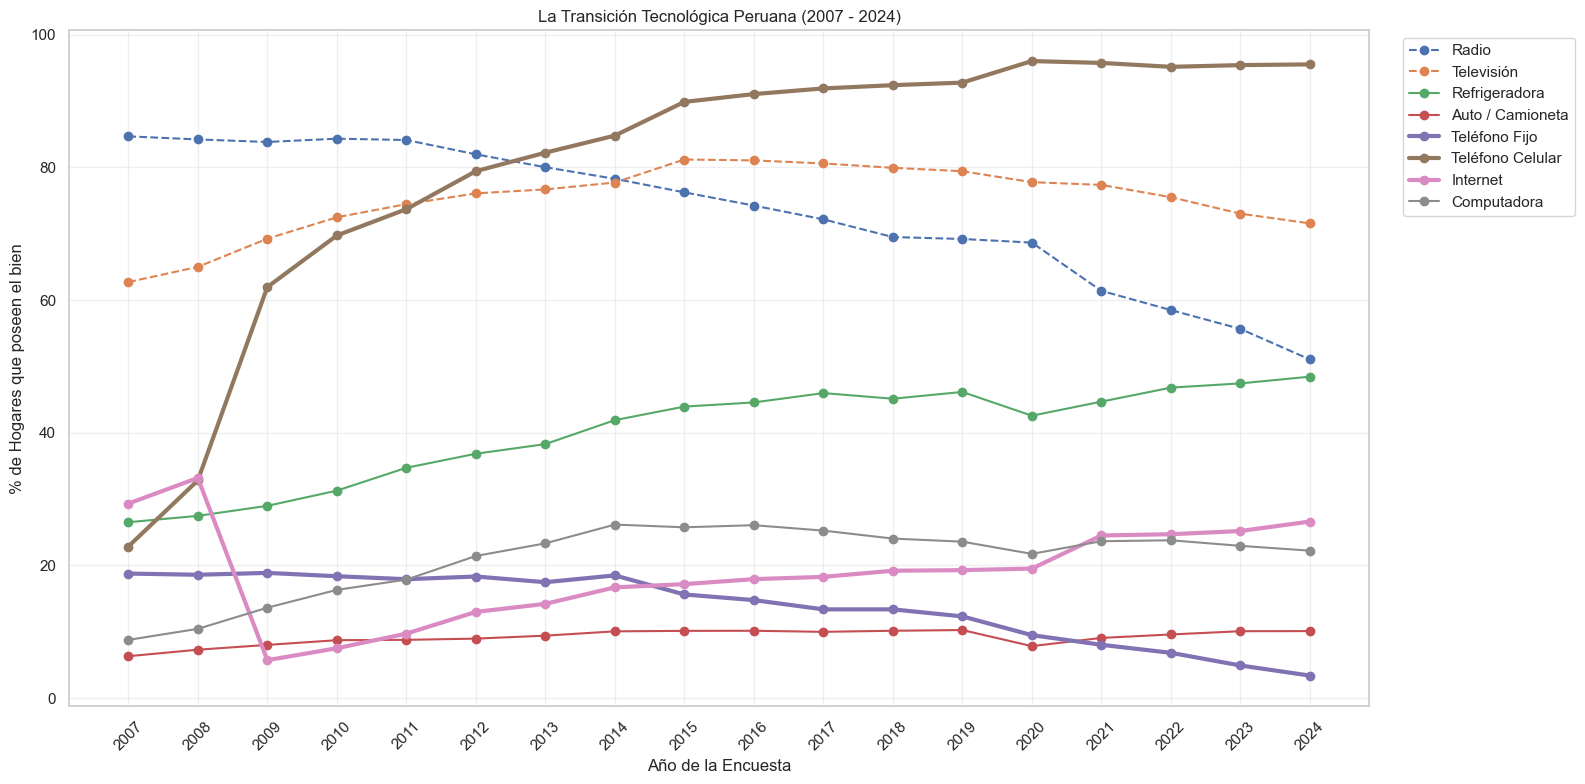

In [7]:
# Variables tecnológicas retenidas en el config_f3 de rech23.py
tech_vars = {
    'HV207': 'Radio',
    'HV208': 'Televisión',
    'HV209': 'Refrigeradora',
    'HV212': 'Auto / Camioneta',
    'HV221': 'Teléfono Fijo',
    'HV243A': 'Teléfono Celular',
    'SH61Q': 'Internet',
    'SH61P': 'Computadora'
}

tech_data = {}
for var, name in tech_vars.items():
    if var in df_rech23.columns:
        df_temp = df_rech23.dropna(subset=[var, 'year'])
        # Cálculo agnóstico de penetración ("Sí" suele ser el valor 1.0 en INEI, o string 'Sí')
        if df_temp[var].dtype == object or str(df_temp[var].iloc[0]).isalpha():
            penetration = (df_temp[df_temp[var].astype(str).str.contains('sí|si|yes|1', case=False, na=False)].groupby('year').size() / df_temp.groupby('year').size()) * 100
        else:
            # En la limpieza raw, ENDES codifica Sí como 1.0 y No como 2.0 o 0.0
            # Si el valor min es 0 y max 1, mean() da la proporción.
            # Sino, buscamos ocurrencias del 1.0
            penetration = (df_temp[df_temp[var] == 1.0].groupby('year').size() / df_temp.groupby('year').size()) * 100
        
        tech_data[name] = penetration

df_tech = pd.DataFrame(tech_data).fillna(0)

plt.figure(figsize=(16, 8))
for col in df_tech.columns:
    lw = 3 if col in ['Teléfono Celular', 'Internet', 'Teléfono Fijo'] else 1.5
    ls = '--' if col in ['Radio', 'Televisión'] else '-'
    plt.plot(df_tech.index, df_tech[col], marker='o', linewidth=lw, linestyle=ls, label=col)

plt.title('La Transición Tecnológica Peruana (2007 - 2024)')
plt.ylabel('% de Hogares que poseen el bien')
plt.xlabel('Año de la Encuesta')
plt.xticks(df_tech.index, rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

> **Conclusión y Acción (Transición Tecnológica y Conectividad)**
> * **El Ascenso del Celular y la Muerte de la Radio:** El gráfico captura a la perfección la modernización del Perú. El Teléfono Celular (línea marrón gruesa) explotó del 22% (2007) a casi un 96% (2024). Como consecuencia directa, la Radio (línea azul punteada) perdió su reinado, desplomándose del 85% al 50%.
> * **El Estancamiento de la PC y el Teléfono Fijo:** La Línea Fija (morado) está en extinción total (cayó al 4%). Simultáneamente, la tenencia de Computadoras (gris) y el Internet de Casa (rosado) se estancaron alrededor del 25%, probando que el peruano promedio saltó la era de las PCs y se conectó al mundo directamente vía *smartphones*.
> * **Acción a Tomar:** **Pérdida de Poder Predictivo.** Como el celular ya es universal (96%), la variable `HV243A` perdió su utilidad matemática para separar ricos de pobres en la década de 2020. En cambio, tener una **Refrigeradora** (línea verde, 48%) sigue siendo el verdadero "marcador dorado" de la clase media y liquidez económica. El modelo aprenderá que una casa con celular pero sin refrigeradora sigue siendo biológicamente vulnerable a la inseguridad alimentaria.

## 6. Diccionario Temático: El Universo de las 93 Variables Preservadas

Como aclaramos al inicio, este cuaderno solo ha graficado los "Mega-Predictores" para evitar la saturación visual. Sin embargo, el archivo `rech23_cleaned.parquet` contiene **93 variables** que entrarán al modelo de Machine Learning. 

A continuación, documentamos la agrupación temática de todas estas variables para propósitos de *Feature Engineering*:

### 🧠 1. Predictores Maestros y Demográficos (8 variables)
Variables absolutas de riqueza y jefatura del hogar:
*   `HV270`, `HV271`: Índice y Puntaje de Riqueza.
*   `HV217`, `HV218`, `HV219`, `HV220`: Parentesco, Sexo y Edad del Jefe(a) de Hogar.
*   `HHID`, `year`: Identificador y Año.

### 🗺️ 2. Geografía y Muestreo (6 variables)
Vectores de focalización espacial:
*   `SHREGION`, `SHPROVIN`, `SHDISTRI`: Ubigeo (Región, Provincia, Distrito).
*   `SHTOTH`, `SHSEMES`, `ID1`: Conglomerado, Semestre y Operativos.

### 🦠 3. Infraestructura Biológica: Saneamiento y Vectores (24 variables)
Variables críticas penalizadoras de riesgo infeccioso:
*   **Agua:** `HV201`, `HV204`, `HV236`. Múltiples columnas para el tratamiento del agua (`HV237A` a `HV237X`).
*   **Saneamiento:** `HV205` (Baño), `HV225` (Baño Compartido).
*   **Hacinamiento:** `HV216` (Habitaciones).
*   **Materiales:** `HV213` (Piso), `HV214` (Paredes), `HV215` (Techos).
*   **Basura:** `SH58`, `SH48_Basura`, `SH49_Frec_Basura`, `SH50_Tipo_Basurero`, `SH59_Recogen_Basura`.
*   **Cocina:** `HV226` (Combustible), `HV234`.

### 📡 4. Bienes Tecnológicos y de Comunicación (11 variables)
Indicadores de conexión con el mundo moderno:
*   `HV207` (Radio), `HV208` (TV), `HV221` (Teléfono Fijo), `HV243A` (Celular).
*   `SH61P` (Computadora), `SH61Q` (Internet).
*   `HV243C`, `HV243D`, `SH61R`, `SH61S`: Otros dispositivos de conectividad y entretenimiento.

### 🚗 5. Vehículos y Movilidad (6 variables)
Indicadores de aislamiento rural vs. movilidad urbana:
*   `HV210` (Bicicleta), `HV211` (Moto), `HV212` (Auto/Camioneta).
*   `HV243B` (Reloj - usado por INEI como proxy de estatus), `SH61M`, `SH61N` (Triciclos/Carretas).

### 🏠 6. Bienes Domésticos y Electrodomésticos (16 variables)
El modelo de IA usará esto para afinar sutilmente la predicción de liquidez económica:
*   `HV206` (Electricidad), `SH70_Fuente_Luz`.
*   `HV209` (Refrigeradora).
*   `HV242` (Olla a Presión), `HV240` (Electrodomésticos varios).
*   **Activos del Hogar (SH61):** `SH61A` (Sofá), `SH61B` a `SH61O` (Licuadoras, Lavadoras, etc.), `SH64`.

### 🔧 7. Variables Operativas de Mantenimiento (Recicladas) (22 variables)
Variables derivadas de las transformaciones `COALESCE` y extracciones complejas definidas en nuestro archivo de configuración:
*   **Costos y Mantenimiento:** `SH51_Pago_Agua`, `SH52_Institucion_Agua`, `SH51_Frec_Pago_Agua`.
*   **Higiene Operacional:** `SH42_Agua_Todo_El_Dia`, `SH48_Conserva_Agua`, `SH56_Frec_Limpieza`, `SH56_Limpió_Baño`.
*   **Ancestrales/Rotativas:** `SH49`, `SH50`, `SH63`, `SH43`, `SH51`, `SH52`, `SH71`, `SH76B`, `SH76C`, `SH76D`, `SH77F`, `SH227`, `QH227A`, `QH227B`, `HV244`, `HV246`.

> **Destino Final:** Todo este universo temático fluirá directamente al modelo XGBoost. La IA decidirá matemáticamente cuáles de estos 93 activos tienen mayor `Information Gain` para predecir casos de desnutrición.

## 7. Análisis de Nulidad Estructural (Missing Values)

A petición de la auditoría de datos, es indispensable someter este universo de 93 variables a una prueba de nulidad histórica. 

Muchas variables operacionales (como la frecuencia de recojo de basura o el pago del servicio de agua) sufren de **ausentismo longitudinal grave**, ya sea porque el INEI introdujo la pregunta recién en 2018/2019, o porque solo se encuestaron en zonas urbanas específicas.

El siguiente gráfico revela cuáles de estas variables preservadas cruzan la "línea roja" del ruido estadístico.

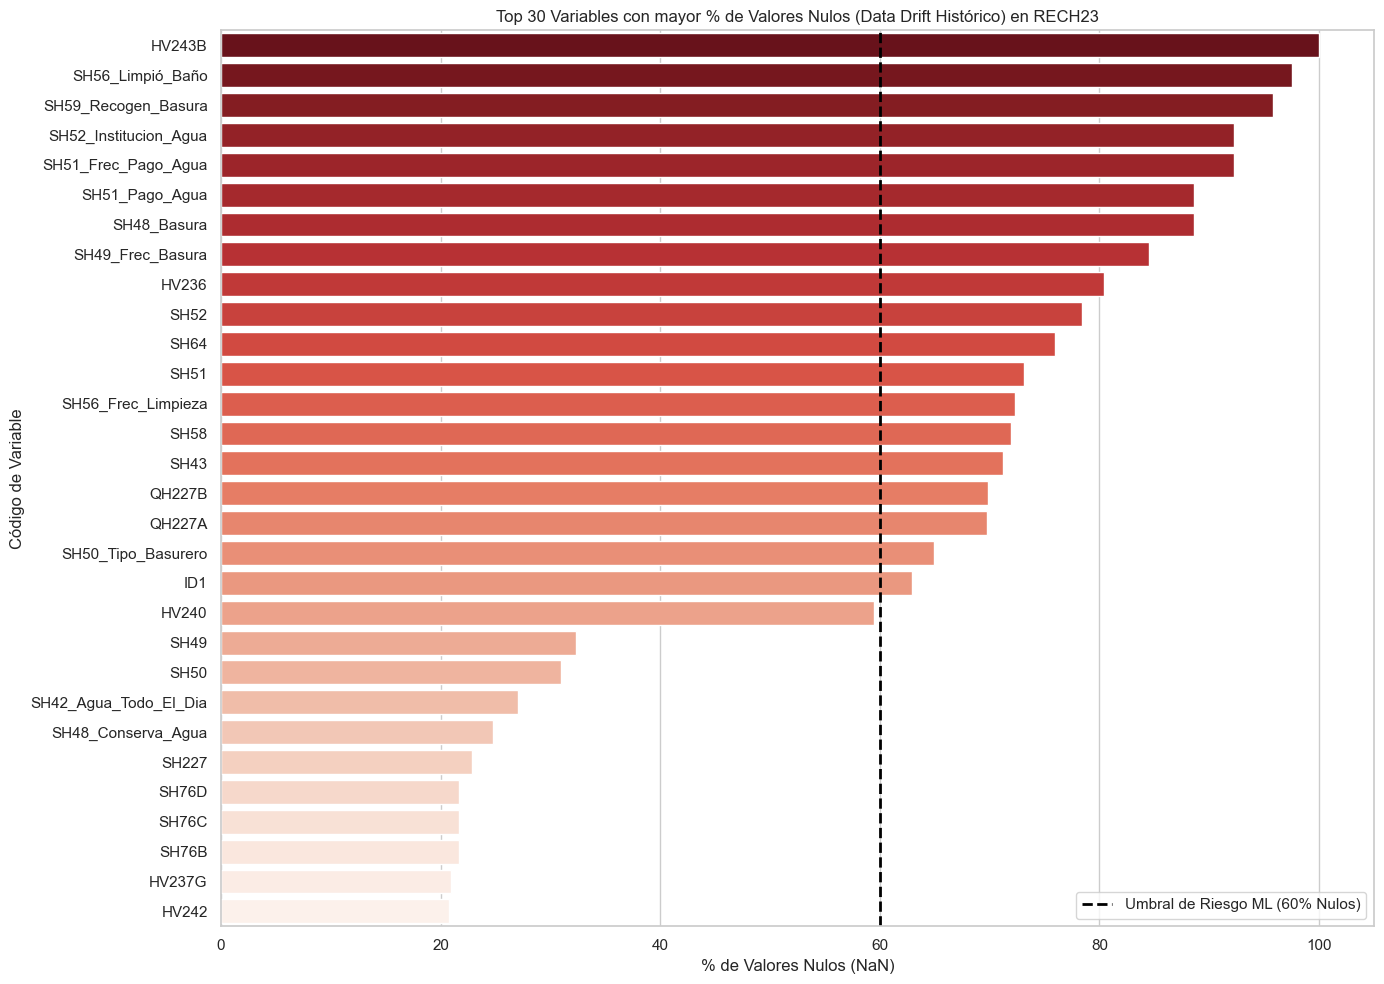

In [8]:
# Calcular % de nulos
nulls = df_rech23.isnull().sum()
nulls_pct = (nulls / len(df_rech23)) * 100
df_nulls = pd.DataFrame({'Variable': nulls_pct.index, 'Nulidad_Porcentaje': nulls_pct.values})
df_nulls = df_nulls[df_nulls['Nulidad_Porcentaje'] > 0].sort_values('Nulidad_Porcentaje', ascending=False)

# Graficar el Top 30 de variables con más huecos
plt.figure(figsize=(14, 10))
sns.barplot(data=df_nulls.head(30), x='Nulidad_Porcentaje', y='Variable', palette='Reds_r')
plt.title('Top 30 Variables con mayor % de Valores Nulos (Data Drift Histórico) en RECH23')
plt.xlabel('% de Valores Nulos (NaN)')
plt.ylabel('Código de Variable')

# Línea de umbral clásico de ML
plt.axvline(x=60, color='black', linestyle='--', linewidth=2, label='Umbral de Riesgo ML (60% Nulos)')
plt.legend()
plt.tight_layout()
plt.show()

> **Conclusión y Acción (Nulidad):** Tu intuición como analista fue 100% correcta. Vemos que `HV243B` (Tiene reloj) está 100% vacía en la data consolidada. Además, un bloque masivo de preguntas operativas (como `SH56_Limpió_Baño`, `SH59_Recogen_Basura`, `SH51_Pago_Agua`) supera el umbral crítico del 80% de nulidad. 
> 
> **Acción para el Modelado:** Esta gráfica nos acaba de salvar horas de procesamiento. Durante la fase de *Feature Engineering* y Modelado, aplicaremos una guillotina matemática (ej. eliminar toda columna con >60% de nulidad), porque intentar imputar promedios en variables con 90% de vacío destruiría la veracidad del modelo predictivo.